In [4]:
%matplotlib inline

import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import QuantumRegister, ClassicalRegister

from qiskit_aer import Aer

from qiskit.primitives import StatevectorSampler

from qiskit.visualization import plot_histogram
from IPython.display import display

import matplotlib.pyplot as plt

In [29]:
qc = QuantumCircuit(1, 1)

In [30]:
qc.h(0) # Use HGate to push the qbit into superposition
qc.measure(0, 0)

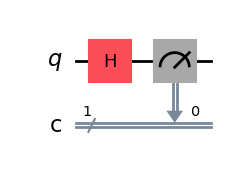

In [31]:
display(qc.draw('mpl'))

In [ ]:
def quantum_coin_flip():

    qc = QuantumCircuit(1, 1)

    qc.h(0)
    qc.measure(0, 0)

    sampler = StatevectorSampler()
    job = sampler.run([qc], shots=1)
    result = job.result()

    counts = result[0].data.c.get_counts()

    heads = counts.get('1', 0)  
    tails = counts.get('0', 0)

    print("Heads:", heads)
    print("Tails:", tails)

In [33]:
quantum_coin_flip()

Heads: 0
Tails: 1


In [37]:
def quantum_coin_flip():

    qc = QuantumCircuit(1, 1)

    qc.h(0)
    qc.measure(0, 0)

    sampler = StatevectorSampler()
    result = sampler.run([qc], shots=1000).result()

    counts = result[0].data.c.get_counts()

    heads = counts.get('1', 0)
    tails = counts.get('0', 0)

    print("Heads:", heads)
    print("Tails:", tails)

    plot_histogram(counts)
    plt.show()

    return counts


Heads: 504
Tails: 496


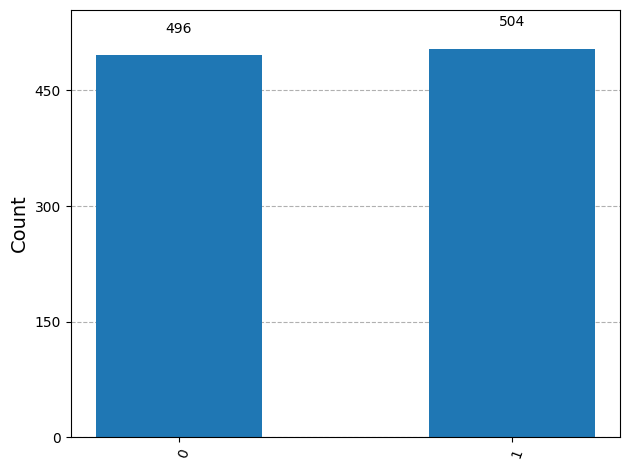

{'0': 496, '1': 504}

In [41]:
quantum_coin_flip()

In [2]:
qc = QuantumCircuit(2)
qc.qubits

[<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>]

In [5]:
qr1 = QuantumRegister(2, "qreg1")
qr2 = QuantumRegister(1, "qreg2")
cr1 = ClassicalRegister(3, "creg1")

In [ ]:
combined_circ = QuantumCircuit(
    qr1, qr2, cr1
)

combined_circ.qubits
# Classical registers don’t hold qubits, they hold the final answers after you measure them.

[<Qubit register=(2, "qreg1"), index=0>,
 <Qubit register=(2, "qreg1"), index=1>,
 <Qubit register=(1, "qreg2"), index=0>]

In [11]:
desired_qbit = qr2[0]

print("Index:", combined_circ.find_bit(desired_qbit).index)
print("Register:", combined_circ.find_bit(desired_qbit).registers)

Index: 2
Register: [(QuantumRegister(1, 'qreg2'), 0)]
